# Q1 · How often are power prices negative?

Day-ahead prices for 8 European bidding zones, 2019 → 2026 (year to date).
Reads the dbt mart `fct_negative_hours` from the DuckDB warehouse (`cd warehouse && uv run dbt build` first).

**Definitions** ([ADR-005](../control-room/04%20Decisions/ADR-005%20Negative%20Hours%20Metric.md)):
hours are summed period durations (15-min and 60-min periods count correctly), years are local calendar years,
"negative" means price < 0 €/MWh and "at or below zero" means ≤ 0. Partial years (2026 to date; Poland 2019,
whose prices were in PLN before 20 Nov 2019) are flagged by `is_partial_year` / `partial_reason`.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

import chart_style as cs

cs.apply_style()

with duckdb.connect(str(cs.WAREHOUSE), read_only=True) as con:
    q1 = con.sql("select * from fct_negative_hours order by zone, local_year").df()
    ytd_end = con.sql(
        "select max(ts_local + to_minutes(resolution_minutes)) from int_prices_local where local_year = 2026"
    ).fetchone()[0]

def eur(v, decimals=0):
    # Format a price with a true minus sign.
    return f"{v:,.{decimals}f}".replace("-", "−")


YTD_LABEL = f"1 Jan to {(ytd_end - pd.Timedelta(minutes=1)):%-d %b} 2026"
CURRENT_YEAR = 2026
print("2026 year to date:", YTD_LABEL)
q1

2026 year to date: 1 Jan to 3 Oct 2026


,zone,local_year,negative_hours,zero_or_negative_hours,covered_hours,expected_hours,completeness,min_price,avg_price,avg_price_negative_periods,is_partial_year,partial_reason
0,BE,2019,71.0,71.00,8759.0,8760.0,0.9999,-500.00,39.35,-52.68,False,NaN
1,BE,2020,136.0,140.00,8784.0,8784.0,1.0000,-115.31,31.88,-18.66,False,NaN
2,BE,2021,159.0,167.00,8760.0,8760.0,1.0000,-70.00,104.12,-19.07,False,NaN
3,BE,2022,112.0,117.00,8760.0,8760.0,1.0000,-100.00,244.53,-27.66,False,NaN
4,BE,2023,222.0,253.00,8760.0,8760.0,1.0000,-120.00,97.27,-10.45,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
59,PT,2022,0.0,4.00,8760.0,8760.0,1.0000,0.00,167.87,NaN,False,NaN
60,PT,2023,0.0,69.00,8760.0,8760.0,1.0000,0.00,88.28,NaN,False,NaN
61,PT,2024,196.0,723.00,8784.0,8784.0,1.0000,-2.00,63.46,-0.26,False,NaN
62,PT,2025,198.5,413.25,8760.0,8760.0,1.0000,-5.00,66.18,-0.97,False,NaN


## Chart 1 · Negative hours per zone and year
Small multiples (one panel per zone) rather than 8 overlapping lines. Panels are ordered by 2025, the last full year.
2026 is year to date and drawn hollow. Poland 2019 is left out (`pln_prices_excluded`).

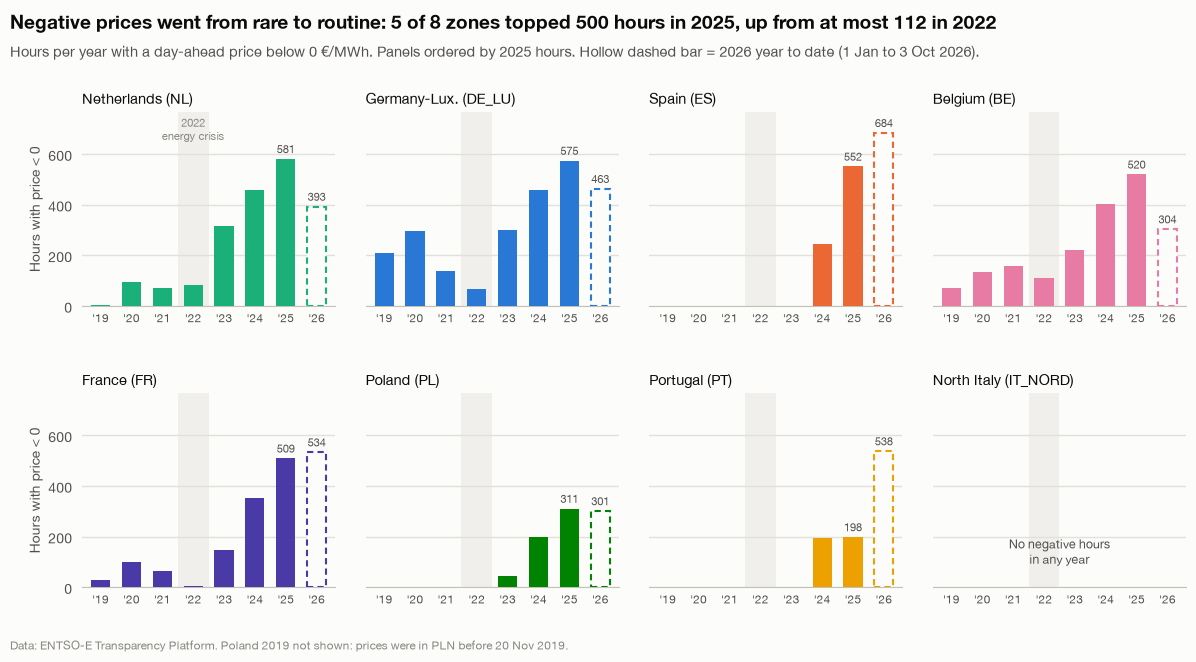

In [2]:
# Full years, plus the current year to date; drop years that are partial for any other reason.
c1 = q1[(~q1.is_partial_year) | (q1.partial_reason == "current_year")]
order = c1[c1.local_year == 2025].sort_values("negative_hours", ascending=False).zone.tolist()
years = list(range(2019, CURRENT_YEAR + 1))
ymax = c1.negative_hours.max()

fig, axes = plt.subplots(2, 4, figsize=(12, 6.6), sharey=True)
fig.subplots_adjust(left=0.07, right=0.99, top=0.83, bottom=0.11, hspace=0.45, wspace=0.12)

for ax, zone in zip(axes.flat, order):
    color = cs.ZONE_COLORS[zone]
    z = c1[c1.zone == zone].set_index("local_year").reindex(years)
    ax.axvspan(2021.5, 2022.5, color=cs.HIGHLIGHT_BAND, zorder=0, lw=0)
    for year, hours in z.negative_hours.items():
        if pd.isna(hours) or hours == 0:
            continue
        if year == CURRENT_YEAR:  # year to date: hollow, dashed outline
            ax.bar(year, hours, width=0.62, facecolor=cs.SURFACE, edgecolor=color,
                   linewidth=1.5, linestyle=(0, (3, 2)), zorder=3)
        else:
            ax.bar(year, hours, width=0.62, color=color, zorder=3)
    # Selective labels: the last full year and the year to date.
    for year in (2025, CURRENT_YEAR):
        hours = z.negative_hours.get(year)
        if pd.notna(hours) and hours > 0:
            ax.text(year, hours + ymax * 0.02, f"{hours:,.0f}", ha="center", va="bottom",
                    fontsize=8, color=cs.INK_SECONDARY)
    if z.negative_hours.fillna(0).max() == 0:
        ax.text(2022.5, ymax * 0.12, "No negative hours\nin any year", ha="center", va="bottom",
                fontsize=9, color=cs.INK_SECONDARY)
    ax.set_title(f"{cs.ZONE_LABELS[zone]} ({zone})", loc="left", fontsize=10.5, color=cs.INK, pad=6)
    ax.set_xticks(years, [f"'{y % 100:02d}" for y in years])
    ax.tick_params(axis="x", length=0, labelsize=8.5)
    ax.set_xlim(years[0] - 0.6, years[-1] + 0.6)  # same years in every panel
    ax.set_ylim(0, ymax * 1.12)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(200))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.spines["bottom"].set_color(cs.AXIS)

axes[0, 0].text(2022, ymax * 1.1, "2022\nenergy crisis", ha="center", va="top",
                fontsize=8, color=cs.INK_MUTED, linespacing=1.1)
for ax in axes[:, 0]:
    ax.set_ylabel("Hours with price < 0")

n_over_500 = (c1[c1.local_year == 2025].negative_hours > 500).sum()
max_2022 = c1[c1.local_year == 2022].negative_hours.max()
cs.add_title(
    fig,
    f"Negative prices went from rare to routine: {n_over_500} of 8 zones topped 500 hours in 2025, "
    f"up from at most {max_2022:,.0f} in 2022",
    "Hours per year with a day-ahead price below 0 €/MWh. Panels ordered by 2025 hours. "
    f"Hollow dashed bar = 2026 year to date ({YTD_LABEL}).",
)
cs.add_source(fig, "Poland 2019 not shown: prices were in PLN before 20 Nov 2019.")
cs.save(fig, "q1_negative_hours_by_zone")
plt.show()

## Chart 2 · Frequency vs depth (2025)
How often prices went negative (x) against how far below zero they went on average (y), one point per zone.
Labels add the lowest price of the year. North Italy is left out: it had no negative hours.

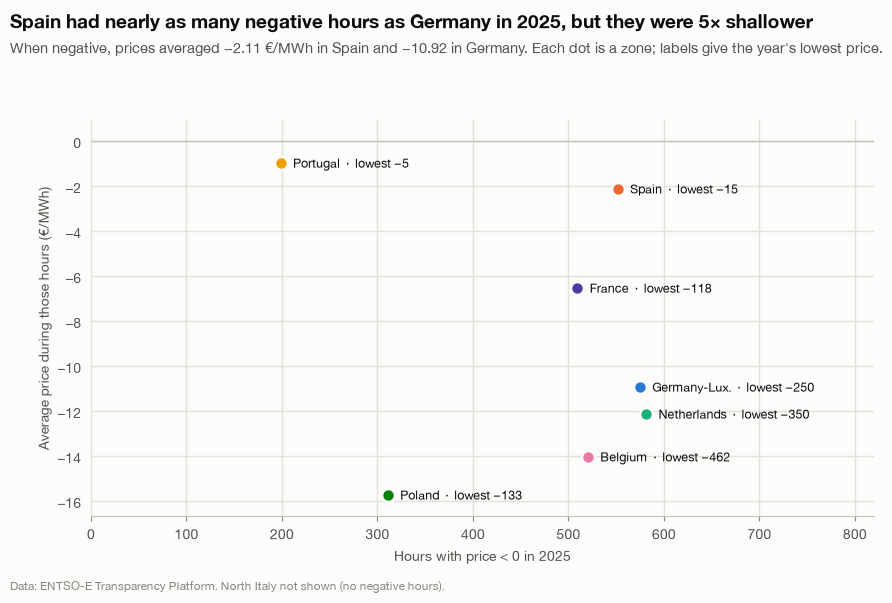

In [3]:
c2 = q1[(q1.local_year == 2025) & (q1.negative_hours > 0)].copy()

fig, ax = plt.subplots(figsize=(9, 6))
fig.subplots_adjust(left=0.1, right=0.97, top=0.80, bottom=0.14)
ax.grid(axis="x", color=cs.GRID, lw=1)
ax.axhline(0, color=cs.AXIS, lw=1, zorder=1)
dots = {}
for r in c2.itertuples():
    ax.scatter(r.negative_hours, r.avg_price_negative_periods, s=90, color=cs.ZONE_COLORS[r.zone],
               edgecolor=cs.SURFACE, linewidth=2, zorder=3)
    dots[r.zone] = (r.negative_hours, r.avg_price_negative_periods)

# Every label sits just right of its own dot, at the dot's height.
labels = {}
for r in c2.itertuples():
    labels[r.zone] = ax.annotate(
        f"{cs.ZONE_LABELS[r.zone]}  ·  lowest {eur(r.min_price)}",
        dots[r.zone], xytext=(9, 0), textcoords="offset points",
        ha="left", va="center", fontsize=9, color=cs.INK)

ax.set_xlim(0, 820)
y_lo, y_hi = c2.avg_price_negative_periods.min(), 0  # data range, plus the zero line
pad = (y_hi - y_lo) * 0.06
ax.set_ylim(y_lo - pad, y_hi + pad)
ax.set_xlabel("Hours with price < 0 in 2025")
ax.set_ylabel("Average price during those hours (€/MWh)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

# Check: each label's nearest dot (in screen space) is its own zone's dot.
fig.canvas.draw()
to_px = ax.transData.transform
for zone, text in labels.items():
    box = text.get_window_extent()
    left_mid = (box.x0, (box.y0 + box.y1) / 2)
    nearest = min(dots, key=lambda z: (to_px(dots[z])[0] - left_mid[0]) ** 2 + (to_px(dots[z])[1] - left_mid[1]) ** 2)
    assert nearest == zone, f"label {zone} is closest to {nearest}"
    for other, xy in dots.items():  # and no label covers another zone's dot
        assert other == zone or not box.contains(*to_px(xy)), f"label {zone} covers {other}"

es = c2.set_index("zone").loc["ES"]
de = c2.set_index("zone").loc["DE_LU"]
cs.add_title(
    fig,
    f"Spain had nearly as many negative hours as Germany in 2025, but they were {de.avg_price_negative_periods / es.avg_price_negative_periods:.0f}× shallower",
    f"When negative, prices averaged {eur(es.avg_price_negative_periods, 2)} €/MWh in Spain and "
    f"{eur(de.avg_price_negative_periods, 2)} in Germany. Each dot is a zone; labels give the year's lowest price.",
)
cs.add_source(fig, "North Italy not shown (no negative hours).")
cs.save(fig, "q1_frequency_vs_depth_2025")
plt.show()

## Chart 3 · Hours at or below zero, 2026 to date: below 0 vs exactly 0
Each bar is a zone's share of hours with a price ≤ 0, split into truly negative (solid) and exactly 0 €/MWh (light tint
of the same colour). North Italy is drawn in neutral grey: its only hours are at exactly 0.

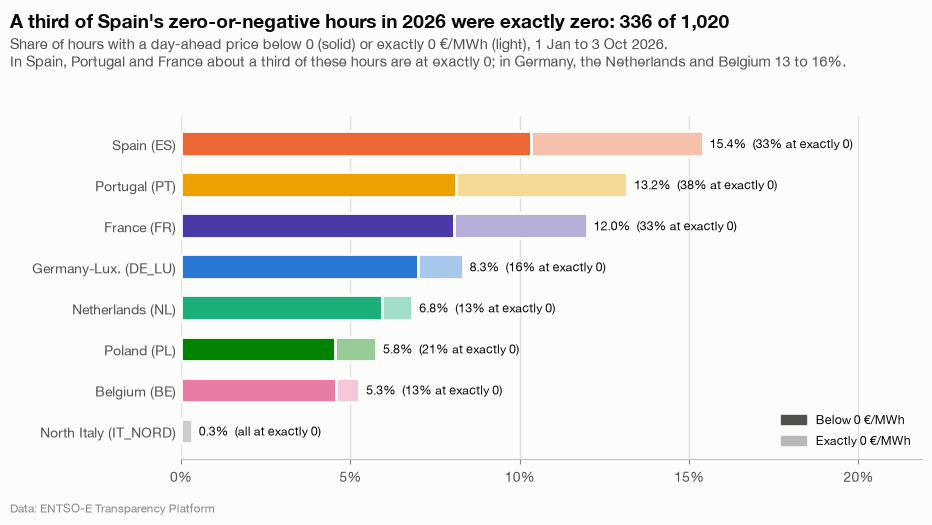

In [4]:
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch


def tint(color, amount=0.6):
    # Mix a colour with the chart surface: amount = how far towards the surface.
    c, s = to_rgb(color), to_rgb(cs.SURFACE)
    return tuple(ci + (si - ci) * amount for ci, si in zip(c, s))


c3 = q1[q1.local_year == CURRENT_YEAR].assign(
    below=lambda d: d.negative_hours / d.covered_hours,
    exactly_zero=lambda d: (d.zero_or_negative_hours - d.negative_hours) / d.covered_hours,
    total=lambda d: d.zero_or_negative_hours / d.covered_hours,
    zero_part=lambda d: (d.zero_or_negative_hours - d.negative_hours) / d.zero_or_negative_hours,
).sort_values("total")

colors = {z: (cs.INK_MUTED if z == "IT_NORD" else cs.ZONE_COLORS[z]) for z in c3.zone}
fig, ax = plt.subplots(figsize=(9.5, 5.2))
fig.subplots_adjust(left=0.19, right=0.97, top=0.78, bottom=0.12)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
names = [f"{cs.ZONE_LABELS[z]} ({z})" for z in c3.zone]
# 2px surface-coloured edges give the gap between the two segments.
ax.barh(names, c3.below, height=0.6, color=[colors[z] for z in c3.zone],
        edgecolor=cs.SURFACE, linewidth=2, zorder=3)
ax.barh(names, c3.exactly_zero, left=c3.below, height=0.6, color=[tint(colors[z]) for z in c3.zone],
        edgecolor=cs.SURFACE, linewidth=2, zorder=3)
for i, r in enumerate(c3.itertuples()):
    note = "all at exactly 0" if r.below == 0 else f"{r.zero_part:.0%} at exactly 0"
    ax.text(r.total + 0.002, i, f"{r.total:.1%}  ({note})", va="center", ha="left",
            fontsize=9, color=cs.INK)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_xlim(0, c3.total.max() * 1.42)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.spines["bottom"].set_color(cs.AXIS)
ax.legend(handles=[Patch(color=cs.INK_SECONDARY, label="Below 0 €/MWh"),
                   Patch(color=tint(cs.INK_SECONDARY), label="Exactly 0 €/MWh")],
          loc="lower right", frameon=False, fontsize=9)

es = c3.set_index("zone").loc["ES"]
es_zero_h = es.zero_or_negative_hours - es.negative_hours
low = c3[c3.zone.isin(["DE_LU", "NL", "BE"])].zero_part
cs.add_title(
    fig,
    f"A third of Spain's zero-or-negative hours in 2026 were exactly zero: "
    f"{es_zero_h:,.0f} of {es.zero_or_negative_hours:,.0f}",
    f"Share of hours with a day-ahead price below 0 (solid) or exactly 0 €/MWh (light), {YTD_LABEL}.\n"
    f"In Spain, Portugal and France about a third of these hours are at exactly 0; "
    f"in Germany, the Netherlands and Belgium {low.min() * 100:.0f} to {low.max():.0%}.",
)
cs.add_source(fig)
cs.save(fig, "q1_share_at_or_below_zero_2026")
plt.show()

## Numbers quoted in the findings

In [5]:
cols = ["zone", "local_year", "negative_hours", "zero_or_negative_hours", "covered_hours",
        "avg_price_negative_periods", "min_price", "is_partial_year", "partial_reason"]
q1[q1.local_year.isin([2022, 2025, 2026])][cols].sort_values(["local_year", "zone"])

,zone,local_year,negative_hours,zero_or_negative_hours,covered_hours,avg_price_negative_periods,min_price,is_partial_year,partial_reason
3,BE,2022,112.00,117.00,8760.0,-27.66,-100.00,False,NaN
11,DE_LU,2022,69.00,75.00,8760.0,-2.08,-19.04,False,NaN
19,ES,2022,0.00,3.00,8760.0,NaN,0.00,False,NaN
27,FR,2022,4.00,8.00,8760.0,-0.68,-1.44,False,NaN
35,IT_NORD,2022,0.00,0.00,8760.0,NaN,10.00,False,NaN
43,NL,2022,85.00,110.00,8760.0,-34.61,-222.36,False,NaN
51,PL,2022,0.00,0.00,8760.0,NaN,16.33,False,NaN
59,PT,2022,0.00,4.00,8760.0,NaN,0.00,False,NaN
6,BE,2025,520.25,577.00,8760.0,-14.03,-462.33,False,NaN
14,DE_LU,2025,574.75,661.50,8760.0,-10.92,-250.32,False,NaN


## Check: no en or em dashes in chart text
House style: ranges use "to", negative numbers use the real minus sign (U+2212). Matplotlib writes every
text string into the SVG as a comment next to its glyph outlines, so the exported files can be checked directly.

In [6]:
DASHES = {"\u2013": "en dash", "\u2014": "em dash"}
svgs = sorted(cs.FIGURES.glob("q1_*.svg"))
assert len(svgs) == 3, svgs
for svg in svgs:
    text = svg.read_text(encoding="utf-8")
    found = [name for char, name in DASHES.items() if char in text]
    assert not found, f"{svg.name} contains: {', '.join(found)}"
print(f"OK: no en/em dashes in {len(svgs)} SVGs:", ", ".join(s.name for s in svgs))

OK: no en/em dashes in 3 SVGs: q1_frequency_vs_depth_2025.svg, q1_negative_hours_by_zone.svg, q1_share_at_or_below_zero_2026.svg
